# CNN Backpropagation Visualization — NumPy

A visual walkthrough of a two-block CNN with explicit forward and backward passes. For the reusable, gradient-checked implementation, see `src/cnn_backprop/`.


# Pipeline


In [ ]:
# ==================================================================
# PIPELINE: MÔ HÌNH CNN THỦ CÔNG (HANDCRAFTED CNN) - 2 CONV LAYERS
# ==================================================================
#
# Cấu trúc mạng (Architecture):
# -----------------------------
# 1. INPUT            : Ảnh MNIST (28 x 28 x 1)
#      ↓
# [BLOCK 1]
# 2. CONV 1 + RELU 1  : Trích xuất đặc trưng tầng thấp (cạnh, nét)
# 3. POOL 1           : Giảm chiều dữ liệu lần 1
#      ↓
# [BLOCK 2]
# 4. CONV 2 + RELU 2  : Trích xuất đặc trưng tầng cao (hình dạng phức tạp)
# 5. POOL 2           : Giảm chiều dữ liệu lần 2 (Đặc trưng cô đọng nhất)
#      ↓
# [CLASSIFIER]
# 6. FLATTEN          : Duỗi phẳng ma trận thành vector 1 chiều
# 7. FC 1             : Lớp ẩn (Fully Connected Layer 1)
# 8. DROPOUT          : Tắt ngẫu nhiên nơ-ron để chống học vẹt (Overfitting)
# 9. FC 2             : Lớp đầu ra (Fully Connected Layer 2) -> 10 lớp
#      ↓
# 10. SOFTMAX         : Tính xác suất dự đoán (0-9)
#
# -----------------------------
# Quy trình Backprop (Lan truyền ngược):
# -----------------------------
# * Loss Function     : Cross-Entropy
# * Optimization      : SGD (Trọng số W được cập nhật trực tiếp trong hàm .backward(lr))
# * Luồng Gradient    : Loss → FC2 → Dropout → FC1 → Flatten → Pool2 → Conv2 → Pool1 → Conv1

# 1 — Import thư viện & đặt seed

In [ ]:
# CELL 1
# ======================
# Import & seed
# ======================
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# 2 — Load MNIST (chỉ lấy vài ảnh)

In [ ]:
# CELL 2
# ======================
# Load MNIST (rất ít ảnh)
# ======================
from tensorflow.keras.datasets import mnist

(X_train, y_train), _ = mnist.load_data()

# Chỉ lấy 16 ảnh để demo
BATCH_SIZE = 16
X = X_train[:BATCH_SIZE]
y = y_train[:BATCH_SIZE]

# Chuẩn hóa + reshape
X = X.reshape(BATCH_SIZE, 1, 28, 28) / 255.0

# One-hot label
Y = np.eye(10)[y]

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (16, 1, 28, 28)
Y shape: (16, 10)


# 3 — Visualize dữ liệu MNIST

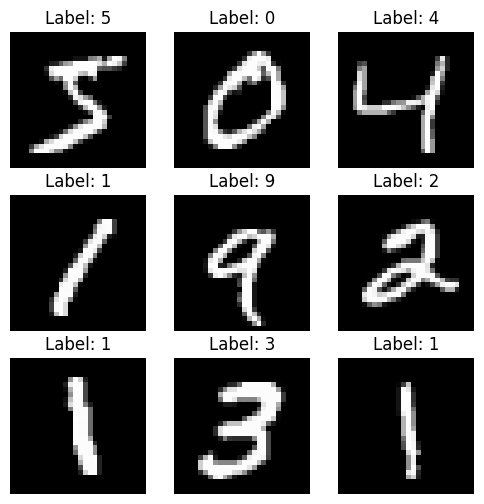

In [ ]:
# CELL 3
# ======================
# Hiển thị ảnh MNIST
# ======================
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i,0], cmap="gray")
    plt.title(f"Label: {y[i]}")
    plt.axis("off")
plt.show()


# 4 — Các hàm toán học cơ bản

In [ ]:
# CELL 4
# ======================
# Utils
# ======================
def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def cross_entropy(A, Y):
    B = Y.shape[0]
    return -np.sum(Y * np.log(A + 1e-9)) / B

def accuracy(A, Y):
    return np.mean(np.argmax(A,1) == np.argmax(Y,1))


# 5 — Conv2D (forward + backward)

In [ ]:
class Conv2D:
    def __init__(self, Cin, Cout, K):
        self.W = np.random.randn(Cout, Cin, K, K) * 0.1
        self.b = np.zeros(Cout)

    def forward(self, X):
        self.X = X
        B,C,H,W = X.shape
        F,_,K,_ = self.W.shape
        Hout, Wout = H-K+1, W-K+1

        Z = np.zeros((B,F,Hout,Wout))
        for b in range(B):
            for f in range(F):
                for i in range(Hout):
                    for j in range(Wout):
                        Z[b,f,i,j] = np.sum(
                            X[b,:,i:i+K,j:j+K] * self.W[f]
                        ) + self.b[f]
        return Z

    def backward(self, dZ, lr):
        B,F,Hout,Wout = dZ.shape
        _,C,H,W = self.X.shape
        _,_,K,_ = self.W.shape

        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dX = np.zeros_like(self.X)

        for b in range(B):
            for f in range(F):
                db[f] += np.sum(dZ[b,f])
                for i in range(Hout):
                    for j in range(Wout):
                        dW[f] += dZ[b,f,i,j] * self.X[b,:,i:i+K,j:j+K]
                        dX[b,:,i:i+K,j:j+K] += dZ[b,f,i,j] * self.W[f]

        self.W -= lr * dW
        self.b -= lr * db
        return dX


# 6 — ReLU & MaxPooling

In [ ]:
# CELL 6
# ======================
# ReLU, MaxPool, Flatten, Dropout
# ======================

class ReLU:
    def forward(self, Z):
        self.Z = Z
        return np.maximum(0, Z)

    def backward(self, dA):
        return dA * (self.Z > 0)


class MaxPool2x2:
    def forward(self, X):
        self.X = X
        B, C, H, W = X.shape

        H2 = H // 2
        W2 = W // 2

        Z = np.zeros((B, C, H2, W2))
        self.mask = np.zeros_like(X)

        for b in range(B):
            for c in range(C):
                for i in range(H2):
                    for j in range(W2):
                        patch = X[b, c, 2*i:2*i+2, 2*j:2*j+2]
                        winner = int(np.argmax(patch))
                        Z[b, c, i, j] = patch.flat[winner]
                        row, col = divmod(winner, 2)
                        self.mask[b, c, 2*i + row, 2*j + col] = 1
        return Z

    def backward(self, dZ):
        B, C, H, W = self.X.shape
        dX = np.zeros_like(self.X)

        for b in range(B):
            for c in range(C):
                for i in range(dZ.shape[2]):
                    for j in range(dZ.shape[3]):
                        dX[b, c, 2*i:2*i+2, 2*j:2*j+2] += (
                            dZ[b, c, i, j] *
                            self.mask[b, c, 2*i:2*i+2, 2*j:2*j+2]
                        )
        return dX


class Flatten:
    def forward(self, X):
        self.shape = X.shape
        return X.reshape(X.shape[0], -1)

    def backward(self, dF):
        return dF.reshape(self.shape)


class Dropout:
    def __init__(self, p=0.5):
        self.p = p
        self.mask = None

    def forward(self, X, train=True):
        if train:
            self.mask = (np.random.rand(*X.shape) > self.p) / (1 - self.p)
            return X * self.mask
        else:
            self.mask = None
            return X

    def backward(self, dX):
        if self.mask is None:
            return dX
        return dX * self.mask


# 7 — Fully Connected

In [ ]:
# CELL 7
class FC:
    def __init__(self, d, n):
        self.W = np.random.randn(d,n) * 0.01
        self.b = np.zeros((1,n))

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dZ, lr):
        dW = self.X.T @ dZ
        db = np.sum(dZ, axis=0, keepdims=True)
        dX = dZ @ self.W.T

        self.W -= lr * dW
        self.b -= lr * db
        return dX


# 8 — Khởi tạo model

In [ ]:
# CELL 8
# ======================
# Khởi tạo model
# ======================

conv1 = Conv2D(1, 8, 3)     # 28x28 → 26x26
relu1 = ReLU()
pool1 = MaxPool2x2()       # 26x26 → 13x13

conv2 = Conv2D(8, 16, 3)   # 13x13 → 11x11
relu2 = ReLU()
pool2 = MaxPool2x2()       # 11x11 → 5x5

flatten = Flatten()
fc1 = FC(16*5*5, 64)
drop = Dropout(0.5)
fc2 = FC(64, 10)

# scale weight cho dễ hội tụ
conv1.W *= 2
conv2.W *= 2
fc1.W   *= 2
fc2.W   *= 2


# 9 — 1 bước train (thể hiện rõ backprop)

In [ ]:
# CELL 9
def train_step(X, Y, lr=0.01):
    # ===== Forward =====
    Z1 = conv1.forward(X)
    A1 = relu1.forward(Z1)
    P1 = pool1.forward(A1)

    Z2 = conv2.forward(P1)
    A2 = relu2.forward(Z2)
    P2 = pool2.forward(A2)

    F  = flatten.forward(P2)
    Z3 = fc1.forward(F)
    D  = drop.forward(Z3, train=True)
    Z4 = fc2.forward(D)

    A4 = softmax(Z4)
    # Z1 -> A1 -> P1 -> Z2 -> A2 -> P2 -> F -> Z3 -> D -> Z4 -> A4

    loss = cross_entropy(A4, Y)
    acc  = accuracy(A4, Y)

    # ===== Backward =====
    dZ4 = (A4 - Y) / Y.shape[0]
    dD  = fc2.backward(dZ4, lr)
    dZ3 = drop.backward(dD)
    dF  = fc1.backward(dZ3, lr)

    dP2 = flatten.backward(dF)
    dA2 = pool2.backward(dP2)
    dZ2 = relu2.backward(dA2)
    dP1 = conv2.backward(dZ2, lr)

    dA1 = pool1.backward(dP1)
    dZ1 = relu1.backward(dA1)
    conv1.backward(dZ1, lr)

    return loss, acc


# visualize_backprop()

In [ ]:
def visualize_backprop(X, Y):
    # Chỉ lấy 1 ảnh để visualize
    x = X[:1]
    y = Y[:1]

    # ======================
    # FORWARD PASS
    # ======================
    Z1 = conv1.forward(x)
    A1 = relu1.forward(Z1)
    P1 = pool1.forward(A1)

    Z2 = conv2.forward(P1)
    A2 = relu2.forward(Z2)
    P2 = pool2.forward(A2)

    F  = flatten.forward(P2)
    Z3 = fc1.forward(F)
    D  = drop.forward(Z3, train=False)   # dropout TẮT khi visualize
    Z4 = fc2.forward(D)
    A4 = softmax(Z4)

    # ======================
    # BACKWARD PASS
    # ======================
    dZ4 = (A4 - y) / y.shape[0]
    dD  = fc2.backward(dZ4, lr=0.0)
    dZ3 = drop.backward(dD)
    dF  = fc1.backward(dZ3, lr=0.0)

    dP2 = flatten.backward(dF)
    dA2 = pool2.backward(dP2)
    dZ2 = relu2.backward(dA2)
    dP1 = conv2.backward(dZ2, lr=0.0)

    dA1 = pool1.backward(dP1)
    dZ1 = relu1.backward(dA1)
    dX  = conv1.backward(dZ1, lr=0.0)

    # ======================
    # VISUALIZATION
    # ======================
    plt.figure(figsize=(10,4))

    plt.subplot(1,4,1)
    plt.title("Input")
    plt.imshow(x[0,0], cmap="gray")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.title("Conv1 Feature")
    plt.imshow(A1[0,0], cmap="viridis")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.title("Gradient |dL/dX|")
    plt.imshow(np.abs(dX[0,0]), cmap="hot")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.title("Softmax Output")
    plt.bar(range(10), A4[0])
    plt.ylim(0,1)

    plt.tight_layout()
    plt.show()

    # ======================
    # RETURN ALL RESULTS
    # ======================
    return {
        # Input
        "input": x,

        # Forward
        "A1_relu1": A1,
        "P1_pool1": P1,
        "A2_relu2": A2,
        "P2_pool2": P2,
        "flatten": F,
        "fc1_output": Z3,
        "softmax_output": A4,

        # Backward
        "gradient_dL_dX": dX
    }


# GỌI visualize_backprop(X, Y) (trước train)

Backpropagation BEFORE training


/tmp/ipython-input-2112826471.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[b,f,i,j] = np.sum(


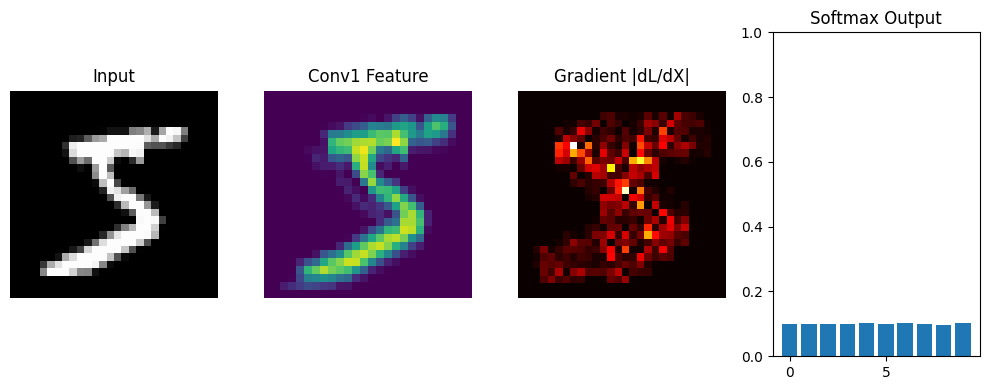

Softmax: [[0.10037291 0.09860636 0.10039996 0.09936166 0.10231288 0.10044608
  0.10139944 0.10083025 0.0950235  0.10124697]]
Gradient dL/dX shape: (1, 1, 28, 28)


In [ ]:
print("Backpropagation BEFORE training")
results = visualize_backprop(X, Y)

print("Softmax:", results["softmax_output"])
print("Gradient dL/dX shape:", results["gradient_dL_dX"].shape)



# 10 — Huấn luyện & chứng minh hiệu quả backprop

In [ ]:
for epoch in range(15):
    loss, acc = train_step(X, Y, lr=0.1)
    print(f"Epoch {epoch+1:02d} | Loss: {loss:.4f} | Acc: {acc:.4f}")


/tmp/ipython-input-2112826471.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[b,f,i,j] = np.sum(


Epoch 01 | Loss: 2.2375 | Acc: 0.2500
Epoch 02 | Loss: 1.7133 | Acc: 0.5625
Epoch 03 | Loss: 1.4237 | Acc: 0.5625
Epoch 04 | Loss: 1.3915 | Acc: 0.4375
Epoch 05 | Loss: 1.1065 | Acc: 0.6875
Epoch 06 | Loss: 0.7681 | Acc: 0.7500
Epoch 07 | Loss: 2.0301 | Acc: 0.5625
Epoch 08 | Loss: 1.6424 | Acc: 0.5000
Epoch 09 | Loss: 1.0288 | Acc: 0.6875
Epoch 10 | Loss: 0.7765 | Acc: 0.9375
Epoch 11 | Loss: 0.4434 | Acc: 0.8750
Epoch 12 | Loss: 0.4313 | Acc: 0.8750
Epoch 13 | Loss: 0.5372 | Acc: 0.8125
Epoch 14 | Loss: 0.4356 | Acc: 0.8125
Epoch 15 | Loss: 0.5136 | Acc: 0.7500


# GỌI visualize_backprop(X, Y) (sau train)

Backpropagation AFTER training


/tmp/ipython-input-2112826471.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Z[b,f,i,j] = np.sum(


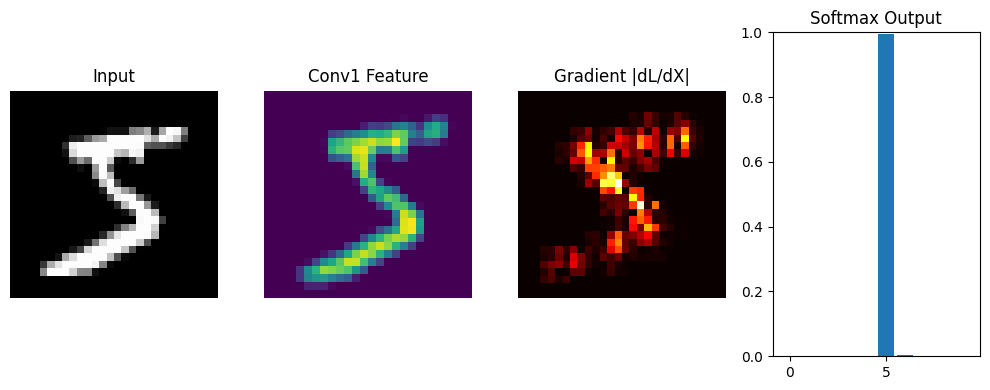

Softmax: [[2.42568305e-04 1.08919565e-04 7.87497627e-04 2.37702501e-06
  7.36926248e-04 9.94055867e-01 3.74623350e-03 2.09260095e-04
  9.47386053e-05 1.56122659e-05]]
Gradient dL/dX shape: (1, 1, 28, 28)


In [ ]:
print("Backpropagation AFTER training")
results = visualize_backprop(X, Y)

print("Softmax:", results["softmax_output"])
print("Gradient dL/dX shape:", results["gradient_dL_dX"].shape)
